# Data Mining Techniques Assignment 1

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv('dataset_mood_smartphone.csv')


## 1. Data Quality & Logical Structure

In [70]:
print(df.shape)          
print(df.info())         
print(df.head())

(376912, 5)
<class 'pandas.DataFrame'>
RangeIndex: 376912 entries, 0 to 376911
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  376912 non-null  int64  
 1   id          376912 non-null  str    
 2   time        376912 non-null  str    
 3   variable    376912 non-null  str    
 4   value       376710 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 14.4 MB
None
   Unnamed: 0       id                     time variable  value
0           1  AS14.01  2014-02-26 13:00:00.000     mood    6.0
1           2  AS14.01  2014-02-26 15:00:00.000     mood    6.0
2           3  AS14.01  2014-02-26 18:00:00.000     mood    6.0
3           4  AS14.01  2014-02-26 21:00:00.000     mood    7.0
4           5  AS14.01  2014-02-27 09:00:00.000     mood    6.0


From info():
- 376912 records
- 4 attributes: row_number, id, time, variable, value.
(1) id = str
(2) time = str
(3) variable = str
(4) value = float64
(5) Unnamed = int64
- 5 columns
- 202 values missing in the value category

### Variable value ranges

In [71]:
expected_ranges = {
    "mood": (1, 10),
    "circumplex.arousal": (-2, 2),
    "circumplex.valence": (-2, 2),
    "activity": (0, 1),
    "call": (1, 1),
    "sms": (1, 1),

    "screen": (0, None),
    "appCat.builtin": (0, None),
    "appCat.communication": (0, None),
    "appCat.entertainment": (0, None),
    "appCat.finance": (0, None),
    "appCat.game": (0, None),
    "appCat.office": (0, None),
    "appCat.other": (0, None),
    "appCat.social": (0, None),
    "appCat.travel": (0, None),
    "appCat.unknown": (0, None),
    "appCat.utilities": (0, None),
    "appCat.weather": (0, None),
}

range_table = (
    df.groupby("variable")["value"]
      .agg(count="count", min="min", max="max")
      .sort_index()
)

range_table["observed_range"] = range_table["max"] - range_table["min"]

range_table["expected_min"] = range_table.index.map(lambda v: expected_ranges.get(v, (None, None))[0])
range_table["expected_max"] = range_table.index.map(lambda v: expected_ranges.get(v, (None, None))[1])

def check_range(row):
    min_ok = True if pd.isna(row["expected_min"]) else row["min"] >= row["expected_min"]
    max_ok = True if pd.isna(row["expected_max"]) else row["max"] <= row["expected_max"]
    return min_ok and max_ok

range_table["within_expected_range"] = range_table.apply(check_range, axis=1)

In [72]:
report_range_table = range_table[
    ["count", "min", "max", "observed_range", "expected_min", "expected_max", "within_expected_range"]
]

print(report_range_table.round(3))

                      count        min        max  observed_range  \
variable                                                            
activity              22965      0.000      1.000           1.000   
appCat.builtin        91288 -82798.871  33960.246      116759.117   
appCat.communication  74276      0.006   9830.777        9830.771   
appCat.entertainment  27125     -0.011  32148.677       32148.688   
appCat.finance          939      0.131    355.513         355.382   
appCat.game             813      1.003   5491.793        5490.790   
appCat.office          5642      0.003  32708.818       32708.815   
appCat.other           7650      0.014   3892.038        3892.024   
appCat.social         19145      0.094  30000.906       30000.812   
appCat.travel          2846      0.080  10452.615       10452.535   
appCat.unknown          939      0.111   2239.937        2239.826   
appCat.utilities       2487      0.246   1802.649        1802.403   
appCat.weather          255      1

From this, we can understand that the dataset is a multivariat time series, where more than one variable is tracked over time. Each row is one measurement event with:
- id = participant
- time = timestamp
- variable = which signal was measured
- value = observed value
- unnamed = idex column

The range overview reveals three main patterns: 
1. Bounded variables such as mood, arousal, valence, activity, call, and sms match their expected scales
2. Passive sensing and app-duration variables have very large ranges, indicating broad spread and likely skewness
3. Some duration variables contain negative values, which suggests data quality issues in the raw dataset

In [73]:
duration_vars = [
    "screen",
    "appCat.builtin",
    "appCat.communication",
    "appCat.entertainment",
    "appCat.finance",
    "appCat.game",
    "appCat.office",
    "appCat.other",
    "appCat.social",
    "appCat.travel",
    "appCat.unknown",
    "appCat.utilities",
    "appCat.weather"
]


negative_durations = df[(df["variable"].isin(duration_vars)) & (df["value"] < 0)]
print("Negative duration rows:", len(negative_durations))

print(negative_durations[["id", "time", "variable", "value"]].head(20))

Negative duration rows: 4
             id                     time              variable      value
150040  AS14.02  2014-03-16 15:46:43.769        appCat.builtin    -44.689
159972  AS14.07  2014-04-30 14:18:06.200        appCat.builtin -82798.871
162154  AS14.12  2014-04-02 16:42:16.523        appCat.builtin     -1.218
309805  AS14.02  2014-03-26 21:18:45.144  appCat.entertainment     -0.011


## 2. Data Exploration

In [74]:
n_rows = len(df)
n_cols = df.shape[1]
n_participants = df["id"].nunique()
n_variables = df["variable"].nunique()
time_min = df["time"].min()
time_max = df["time"].max()
missing_value_total = df["value"].isna().sum()

print("Rows:", n_rows)
print("Columns:", n_cols)
print("Unique participants:", n_participants)
print("Unique variables:", n_variables)
print("Time range:", time_min, "to", time_max)
print("Missing values in value:", missing_value_total)

Rows: 376912
Columns: 5
Unique participants: 27
Unique variables: 19
Time range: 2014-02-17 07:00:52.197 to 2014-06-09 00:00:00.000
Missing values in value: 202


In [75]:
variables = sorted(df["variable"].unique())
print("Variables:")
for v in variables:
    print(v)

Variables:
activity
appCat.builtin
appCat.communication
appCat.entertainment
appCat.finance
appCat.game
appCat.office
appCat.other
appCat.social
appCat.travel
appCat.unknown
appCat.utilities
appCat.weather
call
circumplex.arousal
circumplex.valence
mood
screen
sms


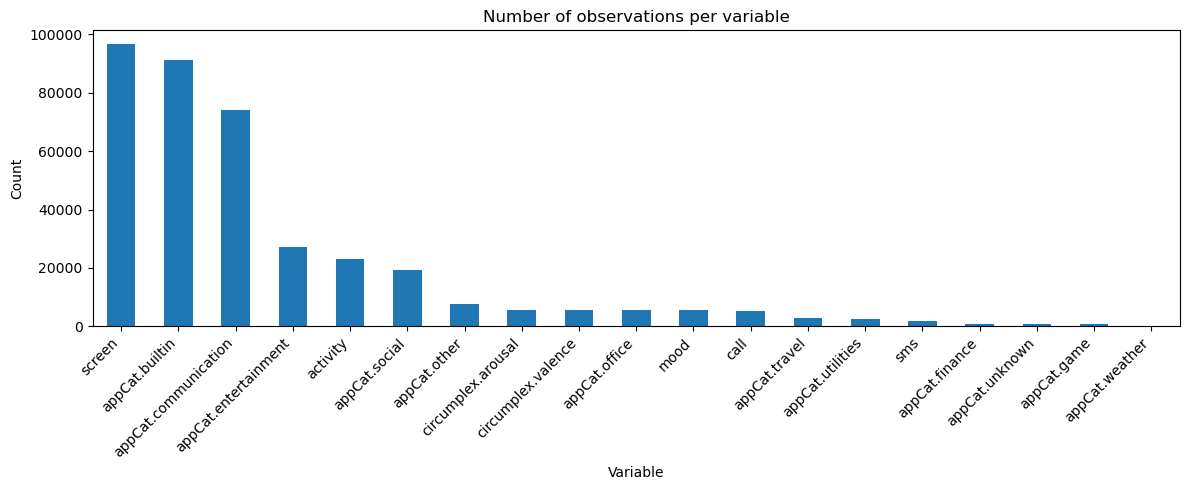

In [76]:
counts_per_variable = df["variable"].value_counts()
plt.figure(figsize=(12, 5))
counts_per_variable.plot(kind="bar")
plt.title("Number of observations per variable")
plt.xlabel("Variable")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [77]:
counts_per_participant = df["id"].value_counts()
print(counts_per_participant)

id
AS14.01    21999
AS14.23    21852
AS14.13    19592
AS14.28    19276
AS14.06    18092
AS14.29    17499
AS14.12    17311
AS14.30    17279
AS14.26    16403
AS14.33    16390
AS14.07    16045
AS14.17    15826
AS14.05    15745
AS14.02    14581
AS14.27    14575
AS14.24    14430
AS14.03    14425
AS14.25    12589
AS14.31    11889
AS14.19    11397
AS14.32    11193
AS14.09    10886
AS14.14     9286
AS14.08     7902
AS14.16     3982
AS14.20     3620
AS14.15     2848
Name: count, dtype: int64


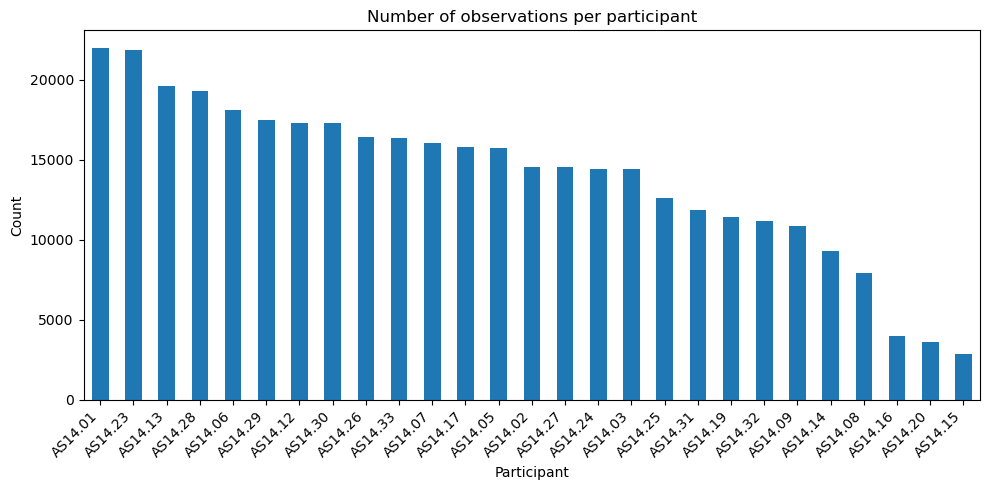

In [78]:
counts_per_participant = df["id"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
counts_per_participant.plot(kind="bar")
plt.title("Number of observations per participant")
plt.xlabel("Participant")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Location and Spread

In [79]:
variable_stats = (
    df.groupby("variable")["value"]
      .agg(
          count="count",
          min="min",
          q1=lambda s: s.quantile(0.25),
          median="median",
          mean="mean",
          q3=lambda s: s.quantile(0.75),
          std="std",
          max="max"
      )
)

variable_stats["range"] = variable_stats["max"] - variable_stats["min"]
variable_stats["iqr"] = variable_stats["q3"] - variable_stats["q1"]

print(variable_stats.round(3))

                      count        min      q1  median     mean       q3  \
variable                                                                   
activity              22965      0.000   0.000   0.022    0.116    0.158   
appCat.builtin        91288 -82798.871   2.020   4.038   18.538    9.922   
appCat.communication  74276      0.006   5.218  16.226   43.344   45.476   
appCat.entertainment  27125     -0.011   1.334   3.391   37.576   14.922   
appCat.finance          939      0.131   4.072   8.026   21.755   20.155   
appCat.game             813      1.003  14.148  43.168  128.392  123.625   
appCat.office          5642      0.003   2.004   3.106   22.579    8.044   
appCat.other           7650      0.014   7.019  10.028   25.811   16.829   
appCat.social         19145      0.094   9.030  28.466   72.402   75.372   
appCat.travel          2846      0.080   5.086  18.144   45.731   47.227   
appCat.unknown          939      0.111   5.018  17.190   45.553   44.430   
appCat.utili

### Distrubutions

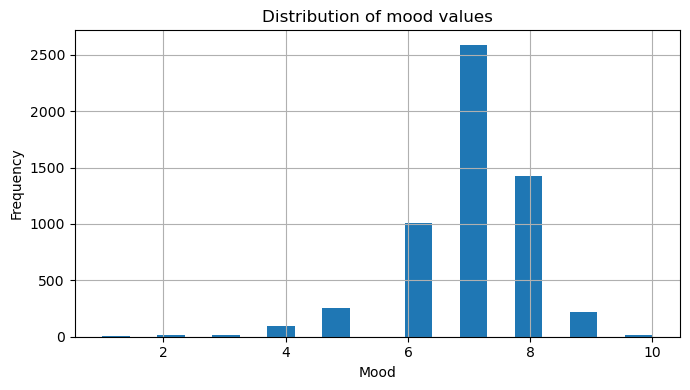

In [80]:
mood_df = df[df['variable'] == 'mood'].copy()
screen_df = df[df['variable'] == 'screen'].copy()

plt.figure(figsize=(7, 4))
mood_df['value'].dropna().hist(bins=20)
plt.title("Distribution of mood values")
plt.xlabel("Mood")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

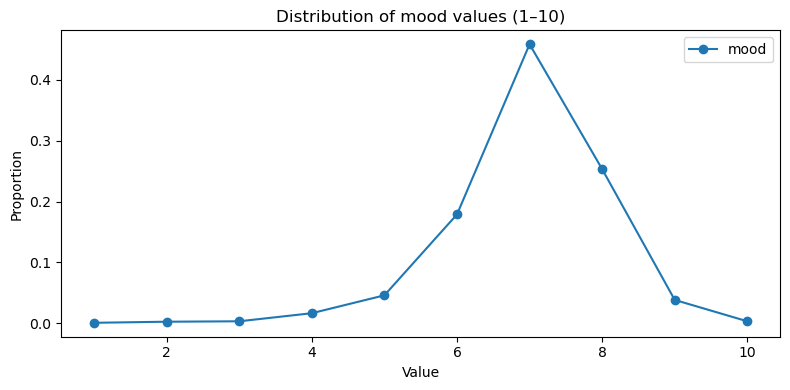

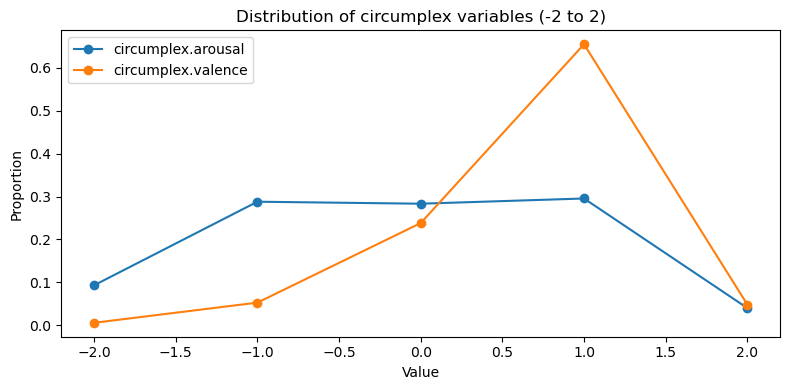

In [81]:
def plot_discrete_distribution(df, variables, x_values=None, normalize=True, title=None):
    plt.figure(figsize=(8, 4))
    
    for var in variables:
        s = df.loc[df["variable"] == var, "value"].dropna()
        counts = s.value_counts(normalize=normalize).sort_index()
        
        if x_values is not None:
            counts = counts.reindex(x_values, fill_value=0)
        
        plt.plot(counts.index, counts.values, marker="o", label=var)
    
    plt.title(title if title else "Discrete distributions")
    plt.xlabel("Value")
    plt.ylabel("Proportion" if normalize else "Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_discrete_distribution(
    df,
    variables=["mood"],
    x_values=range(1, 11),
    normalize=True,
    title="Distribution of mood values (1–10)"
)

plot_discrete_distribution(
    df,
    variables=["circumplex.arousal", "circumplex.valence"],
    x_values=[-2, -1, 0, 1, 2],
    normalize=True,
    title="Distribution of circumplex variables (-2 to 2)"
)

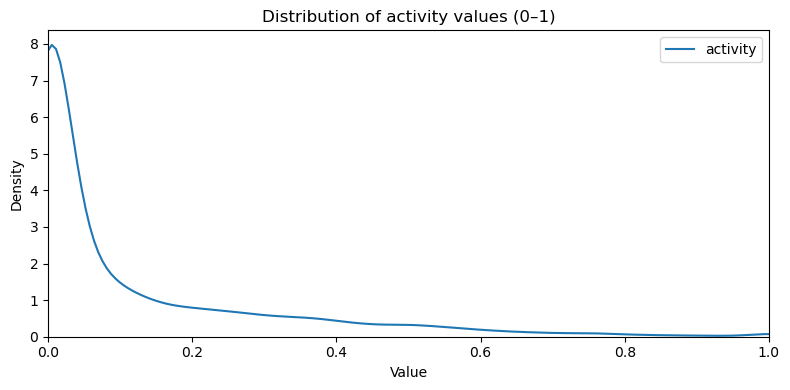

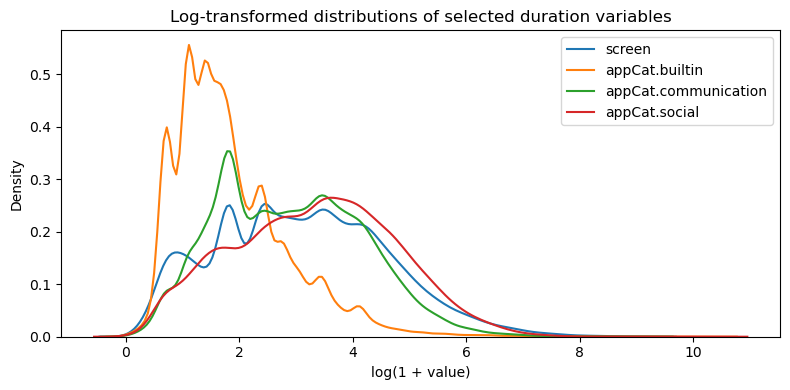

In [82]:
def plot_kde_distribution(df, variables, xlim=None, transform=None, title=None):
    plt.figure(figsize=(8, 4))
    
    for var in variables:
        s = df.loc[df["variable"] == var, "value"].dropna()
        
        if transform == "log1p":
            s = s[s >= 0]
            s = np.log1p(s)
        
        if len(s) > 1 and s.nunique() > 1:
            sns.kdeplot(s, label=var, bw_adjust=1.1)
    
    plt.title(title if title else "Density curves")
    plt.xlabel("log(1 + value)" if transform == "log1p" else "Value")
    plt.ylabel("Density")
    
    if xlim is not None:
        plt.xlim(xlim)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_kde_distribution(
    df,
    variables=["activity"],
    xlim=(0, 1),
    title="Distribution of activity values (0–1)"
)

plot_kde_distribution(
    df,
    variables=["screen", "appCat.builtin", "appCat.communication", "appCat.social"],
    transform="log1p",
    title="Log-transformed distributions of selected duration variables"
)


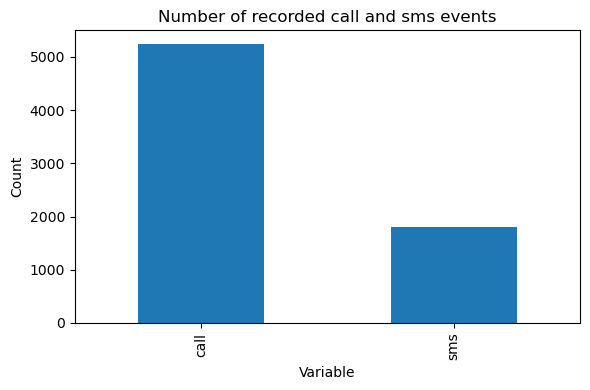

In [83]:
def plot_event_counts(df, variables, title=None):
    counts = (
        df[df["variable"].isin(variables)]["variable"]
        .value_counts()
        .reindex(variables)
    )
    
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")
    plt.title(title if title else "Event counts")
    plt.xlabel("Variable")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_event_counts(
    df,
    variables=["call", "sms"],
    title="Number of recorded call and sms events"
)

To study distributions, variables were grouped by their natural scales and meanings. Variables sharing the same bounded range were plotted together to make their shapes directly comparable. Mood was analyzed on its 1–10 scale, arousal and valence were analyzed together on the -2 to 2 scale, and activity was analyzed on the 0–1 scale. Event indicators such as call and sms were summarized by counts rather than density curves, since they always take the value 1 when present. Duration variables were visualized on a log-transformed scale because their raw distributions were highly skewed and not directly comparable.

### Extended summary

### 

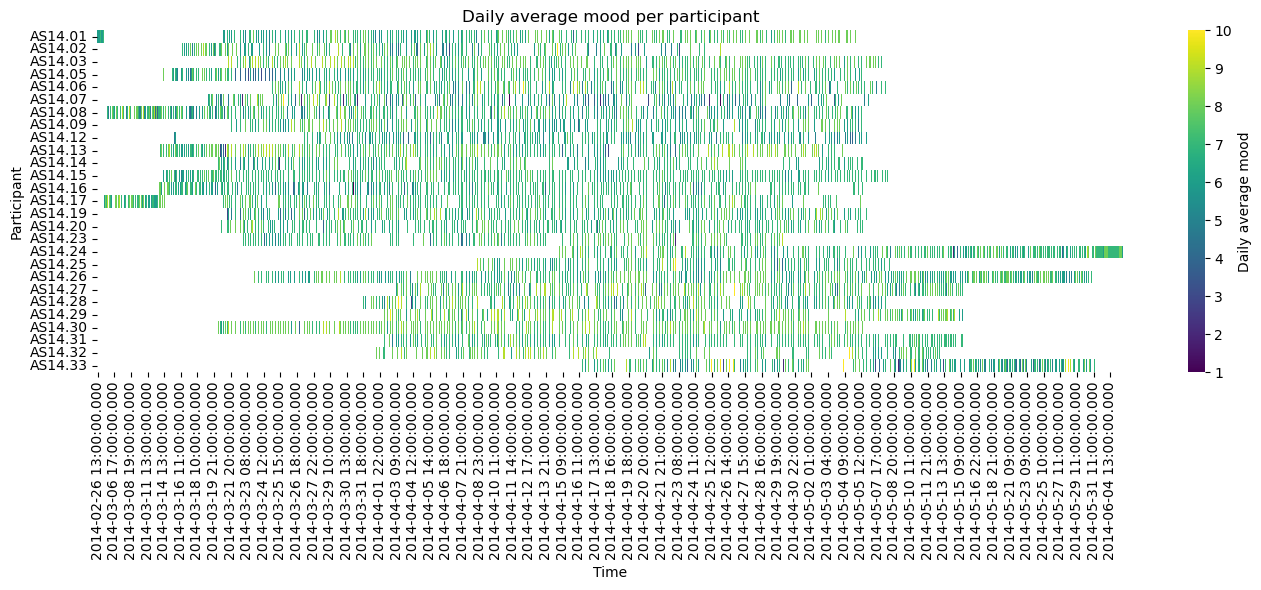

In [84]:
daily_mood = (
    df[df["variable"] == "mood"]
    .groupby(["id", "time"])["value"]
    .mean()
    .reset_index()
)

mood_heatmap = daily_mood.pivot(index="id", columns="time", values="value")

plt.figure(figsize=(14, 6))
sns.heatmap(mood_heatmap, cmap="viridis", cbar_kws={"label": "Daily average mood"})
plt.title("Daily average mood per participant")
plt.xlabel("Time")
plt.ylabel("Participant")
plt.tight_layout()
plt.show()

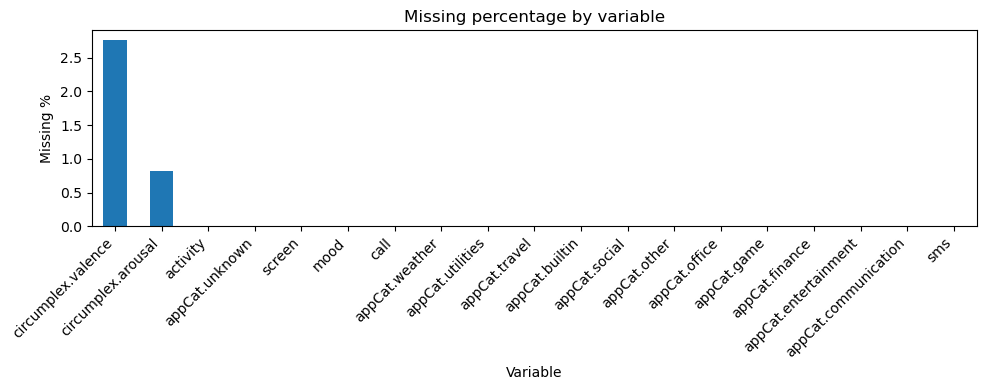

In [85]:
missing_pct = (
    df.groupby("variable")["value"]
      .apply(lambda s: 100 * s.isna().mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))
missing_pct.plot(kind="bar")
plt.title("Missing percentage by variable")
plt.ylabel("Missing %")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

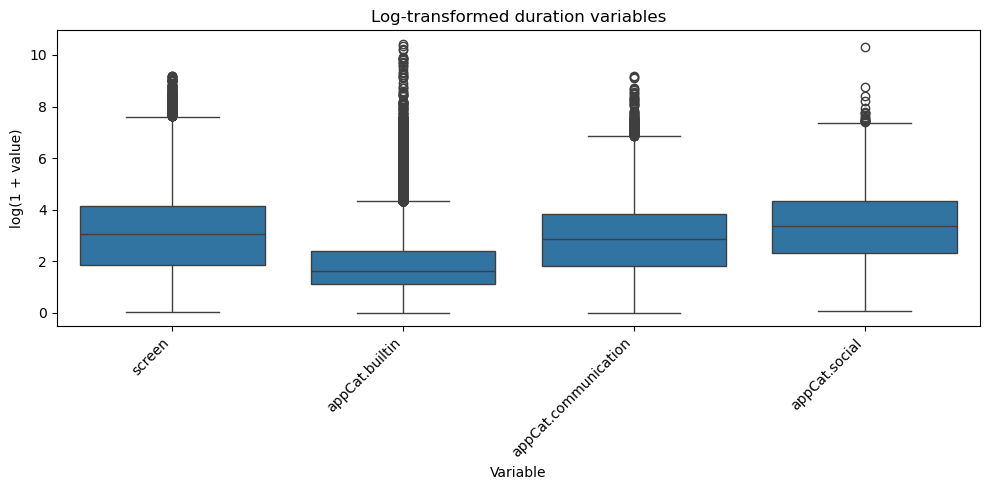

In [86]:
selected_duration_vars = [
    "screen",
    "appCat.builtin",
    "appCat.communication",
    "appCat.social"
]

plot_df = df[df["variable"].isin(selected_duration_vars)].copy()
plot_df = plot_df[plot_df["value"] >= 0].copy()
plot_df["log_value"] = np.log1p(plot_df["value"])

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="variable", y="log_value")
plt.title("Log-transformed duration variables")
plt.xlabel("Variable")
plt.ylabel("log(1 + value)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Because the duration variables showed similar distributional behavior, we visualized a representative subset rather than every variable individually. We selected screen, appCat.builtin, appCat.communication, and appCat.social because they are interpretable, frequently observed, and cover both overall device use and app-specific usage patterns. 

### Dependencies and importance of attributes

In [ ]:
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.normalize()

mean_vars = ["mood", "circumplex.arousal", "circumplex.valence", "activity"]
sum_vars = [
    "screen", "call", "sms",
    "appCat.builtin", "appCat.communication", "appCat.entertainment",
    "appCat.finance", "appCat.game", "appCat.office", "appCat.other",
    "appCat.social", "appCat.travel", "appCat.unknown",
    "appCat.utilities", "appCat.weather"
]

daily_mean = (
    df[df["variable"].isin(mean_vars)]
    .groupby(["id", "date", "variable"])["value"]
    .mean()
    .unstack("variable")
)

daily_sum = (
    df[df["variable"].isin(sum_vars)]
    .groupby(["id", "date", "variable"])["value"]
    .sum()
    .unstack("variable")
)

daily = pd.concat([daily_mean, daily_sum], axis=1).reset_index()

daily[sum_vars] = daily[sum_vars].fillna(0)

daily = daily[daily["mood"].notna()].copy()

daily["next_day_mood"] = daily.groupby("id")["mood"].shift(-1)

daily.head()

variable,id,date,activity,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,...,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,screen,sms,next_day_mood
0,AS14.01,2014-02-26,NaN,-0.25,0.750000,6.250000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.0,0.000,0.000,1.0,0.000000,2.0,6.333333
1,AS14.01,2014-02-27,NaN,0.00,0.333333,6.333333,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.0,0.000,0.000,0.0,0.000000,0.0,6.200000
3,AS14.01,2014-03-21,0.134050,0.20,0.200000,6.200000,3139.218,6280.890,1007.456,49.544,...,239.751,4508.500,915.445,0.0,598.754,0.000,6.0,17978.907000,0.0,6.400000
4,AS14.01,2014-03-22,0.236880,0.60,0.500000,6.400000,731.429,4962.918,93.324,21.076,...,98.143,439.632,37.305,0.0,117.621,0.000,3.0,6142.161000,1.0,6.800000
5,AS14.01,2014-03-23,0.142741,0.20,0.800000,6.800000,1286.246,5237.319,94.346,43.403,...,72.823,900.839,0.000,0.0,30.086,30.386,0.0,6773.832001,0.0,6.000000


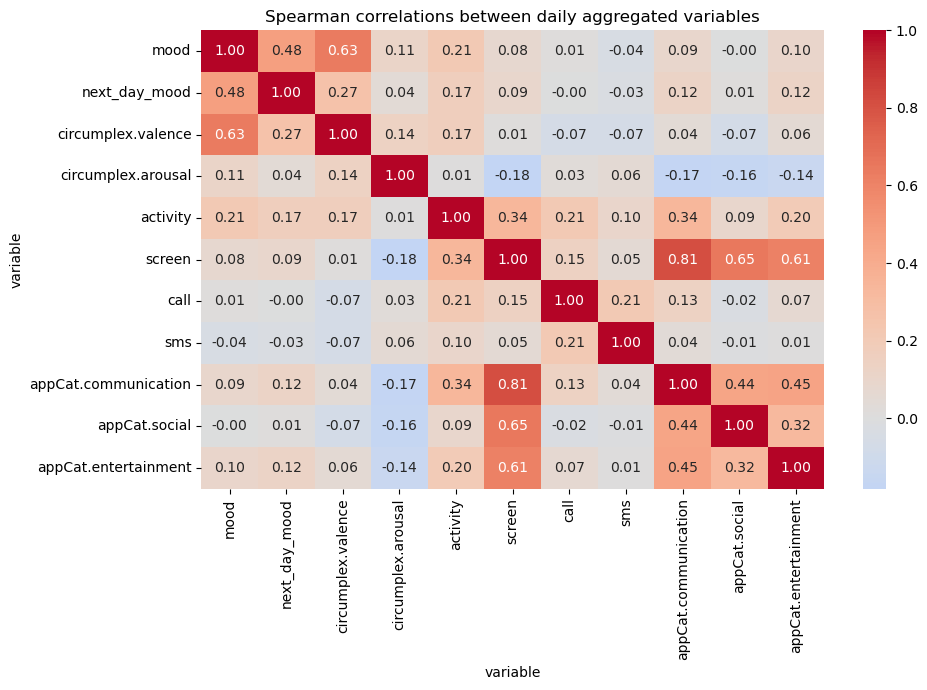

In [88]:
selected_vars = [
    "mood", "next_day_mood",
    "circumplex.valence", "circumplex.arousal", "activity",
    "screen", "call", "sms",
    "appCat.communication", "appCat.social", "appCat.entertainment"
]

corr = daily[selected_vars].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlations between daily aggregated variables")
plt.tight_layout()
plt.show()

In [89]:
target_corr = (
    daily.drop(columns=["id", "date"])
    .corr(method="spearman")["next_day_mood"]
    .drop("next_day_mood")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(target_corr.to_frame("spearman_with_next_day_mood"))

,spearman_with_next_day_mood
variable,
mood,0.475724
circumplex.valence,0.265493
activity,0.168745
appCat.other,0.149887
appCat.office,0.129423
appCat.communication,0.121822
appCat.entertainment,0.119742
appCat.utilities,0.110000
appCat.game,0.103346
